# Retention Campaign — Learning Phase Analysis
## Daily Model Prediction Bias vs Cumulative Installs

This notebook evaluates the learning phase for the new **Retention campaign** product,
analyzing when the D7 retention prediction model stabilizes relative to cumulative installs.

**Key metric**: Retention model bias = `SUM(ret_d7_prob_sum) / SUM(retained_d7) - 1`
- `ret_d7_prob_sum`: sum of predicted D7 retention probabilities per install
- `retained_d7`: actual number of users retained at Day 7
- Bias of 0 = perfect prediction; positive = over-prediction; negative = under-prediction

**Analysis window**: Last 3 months


## Setup and Imports


In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    from google.colab import auth
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

from google.cloud import bigquery

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('✅ Imports complete')
print(f'   Running in Colab: {IN_COLAB}')


✅ Imports complete
   Running in Colab: True


## BigQuery Authentication


In [ ]:
# @title
if IN_COLAB:
    auth.authenticate_user()
    print('✅ Authenticated with Google Cloud')
else:
    print('ℹ️  Using default application credentials (local run)')

project_id = 'unity-data-ads-ad-hoc-prd'
client = bigquery.Client(project=project_id)
print(f'✅ BigQuery client initialized for project: {project_id}')


✅ Authenticated with Google Cloud
✅ BigQuery client initialized for project: unity-data-ads-ad-hoc-prd


## Step 1 — Find Games Running Retention Campaigns (last 3 months)

Identifies all games that have run Retention campaigns in the past 3 months using
`operative_outcomes_dcpi_join_demand`. Returns up to 500 games ordered by recency and spend.


In [ ]:
game_selection_query = '''
WITH base AS (
  SELECT
    target_game_id,
    submit_date,
    spend_sum,
    retained_d7,
    ret_d7_prob_sum
  FROM `unity-data-ads-core-prd.ads_secondary_conversion.operative_outcomes_dcpi_join_demand`
  WHERE app_events_campaign_type = 'RETENTION'
    AND submit_date >= DATE_SUB(CURRENT_DATE('UTC'), INTERVAL 3 MONTH)
    AND submit_date < CURRENT_DATE('UTC')
    AND install_hour IS NOT NULL
),
game_stats AS (
  SELECT
    target_game_id,
    MIN(DATE(submit_date)) AS first_retention_date,
    MAX(DATE(submit_date)) AS last_retention_date,
    COUNT(DISTINCT DATE(submit_date)) AS days_with_data,
    SUM(spend_sum) AS total_spend,
    SUM(retained_d7) AS total_retained_d7,
    SUM(ret_d7_prob_sum) AS total_ret_d7_prob_sum
  FROM base
  GROUP BY target_game_id
  HAVING total_retained_d7 > 10
)
SELECT
  target_game_id,
  first_retention_date,
  last_retention_date,
  days_with_data,
  total_spend,
  total_retained_d7,
  SAFE_DIVIDE(total_ret_d7_prob_sum, total_retained_d7) - 1 AS overall_model_bias
FROM game_stats
ORDER BY total_spend DESC
LIMIT 500
'''

print('🔍 Finding games with Retention campaigns in the last 3 months...')
game_list_df = client.query(game_selection_query).to_dataframe()
game_ids = game_list_df['target_game_id'].astype(int).tolist()

print(f'✅ Found {len(game_ids)} games with sufficient D7 retention data')
print(f'   Date range: {game_list_df["first_retention_date"].min()} to {game_list_df["last_retention_date"].max()}')
print(f'\n📊 Top 10 games by spend:')
display(game_list_df.head(10))


🔍 Finding games with Retention campaigns in the last 3 months...
✅ Found 60 games with sufficient D7 retention data
   Date range: 2026-02-26 to 2026-05-24

📊 Top 10 games by spend:


,target_game_id,first_retention_date,last_retention_date,days_with_data,total_spend,total_retained_d7,overall_model_bias
0,500237245,2026-02-26,2026-05-24,88,407198.825558,37557,0.194573
1,500241521,2026-02-26,2026-05-24,88,118809.702223,3794,0.250121
2,1434564,2026-03-12,2026-05-24,74,89325.038302,7089,0.235861
3,500196051,2026-02-26,2026-05-24,88,88744.218222,2265,0.119697
4,11076,2026-04-01,2026-05-24,35,87487.714703,2967,0.499539
5,1566453,2026-04-28,2026-05-24,27,85693.074838,4077,0.783943
6,500219388,2026-02-26,2026-05-07,71,69843.644976,1486,-0.026545
7,500017356,2026-03-12,2026-05-24,74,61758.281984,3225,0.252833
8,132367,2026-04-23,2026-05-24,32,60903.650557,2392,0.824283
9,500199981,2026-02-26,2026-04-23,57,56367.042179,2748,-0.018820


## Step 2 — Query Daily Model Accuracy & Installs Per Game

For each game: fetches daily installs, retained D7 actuals, predicted D7 probabilities,
and spend. Then computes cumulative installs and rolling 7-day model bias.


In [ ]:
game_ids_str = ', '.join([str(gid) for gid in game_ids])

main_query_template = """WITH daily_data AS ( SELECT target_game_id, DATE(submit_date) AS date, COUNT(*) AS daily_installs, SUM(retained_d7) AS daily_retained_d7, SUM(ret_d7_prob_sum) AS daily_ret_d7_prob_sum, SUM(spend_sum) AS daily_spend FROM `unity-data-ads-core-prd.ads_secondary_conversion.operative_outcomes_dcpi_join_demand` WHERE app_events_campaign_type = 'RETENTION' AND target_game_id IN ({game_ids}) AND submit_date >= DATE_SUB(CURRENT_DATE('UTC'), INTERVAL 3 MONTH) AND submit_date < CURRENT_DATE('UTC') AND install_hour IS NOT NULL AND DATE_DIFF(CURRENT_DATE('UTC'), DATE(install_hour), DAY) >= 8 GROUP BY target_game_id, DATE(submit_date) ) SELECT CAST(target_game_id AS STRING) AS game_id, date, daily_installs, daily_retained_d7, daily_ret_d7_prob_sum, daily_spend, SAFE_DIVIDE(daily_ret_d7_prob_sum, daily_retained_d7) - 1 AS daily_model_bias FROM daily_data WHERE daily_retained_d7 > 0 ORDER BY game_id, date"""
main_query = main_query_template.format(game_ids=game_ids_str)

print(f'🔍 Querying daily data for {len(game_ids)} games...')
print(f'📅 Time filter: Last 3 months, D7 window closed (install >= 8 days ago)')
df = client.query(main_query).to_dataframe()
df['date'] = pd.to_datetime(df['date'])
df['game_id'] = df['game_id'].astype(str)

print(f'✅ Data loaded: {len(df):,} rows')
print(f'🎮 Games found: {df["game_id"].nunique()} games')
print(f'📅 Date range: {df["date"].min()} to {df["date"].max()}')
print('\n📊 Data Preview:')
display(df.head(10))


🔍 Querying daily data for 60 games...
📅 Time filter: Last 3 months, D7 window closed (install >= 8 days ago)
✅ Data loaded: 1,657 rows
🎮 Games found: 60 games
📅 Date range: 2026-02-26 00:00:00 to 2026-05-17 00:00:00

📊 Data Preview:


,game_id,date,daily_installs,daily_retained_d7,daily_ret_d7_prob_sum,daily_spend,daily_model_bias
0,11075,2026-04-02,5,1,1.032154,5.160771,0.032154
1,11075,2026-04-03,9,2,1.886840,12.364363,-0.056580
2,11075,2026-04-04,19,3,3.826961,26.788726,0.275654
3,11075,2026-04-05,13,3,3.246477,22.725340,0.082159
4,11075,2026-04-06,16,6,4.011212,28.078484,-0.331465
5,11075,2026-04-07,17,4,4.032683,28.228785,0.008171
6,11075,2026-04-08,28,10,5.805410,56.046645,-0.419459
7,11075,2026-04-09,119,14,24.473223,361.774717,0.748087
8,11075,2026-04-10,216,37,41.799074,631.971881,0.129705
9,11075,2026-04-11,184,40,35.998932,539.983993,-0.100027


## Step 3 — Feature Engineering

Compute per-game: cumulative installs, cumulative retained D7, 7-day rolling model bias,
and days since campaign start.


In [ ]:
# Sort for windowed operations
df = df.sort_values(['game_id', 'date']).reset_index(drop=True)

# Cumulative installs and retained D7 per game
df['cumulative_installs'] = df.groupby('game_id')['daily_installs'].cumsum()
df['cumulative_retained_d7'] = df.groupby('game_id')['daily_retained_d7'].cumsum()

# Days since campaign start per game
df['campaign_start'] = df.groupby('game_id')['date'].transform('min')
df['days_since_start'] = (df['date'] - df['campaign_start']).dt.days

# 7-day rolling model bias (weighted by retained_d7 volume, min 3 obs)
def rolling_weighted_bias(group):
    group = group.sort_values('date')
    prob_roll = group['daily_ret_d7_prob_sum'].rolling(window=7, min_periods=3).sum()
    actual_roll = group['daily_retained_d7'].rolling(window=7, min_periods=3).sum()
    group['model_bias_ma7'] = prob_roll / actual_roll.replace(0, np.nan) - 1
    return group

df = df.groupby('game_id', group_keys=False).apply(rolling_weighted_bias)

# Absolute bias for threshold analysis
df['abs_model_bias_ma7'] = df['model_bias_ma7'].abs()

print(f'✅ Feature engineering complete')
print(f'   Cumulative installs range: {df["cumulative_installs"].min():,.0f} – {df["cumulative_installs"].max():,.0f}')
print(f'   Model bias range: {df["daily_model_bias"].min():.4f} – {df["daily_model_bias"].max():.4f}')
print(f'   Rolling bias (MA7) range: {df["model_bias_ma7"].dropna().min():.4f} – {df["model_bias_ma7"].dropna().max():.4f}')
display(df[['game_id','date','cumulative_installs','cumulative_retained_d7','days_since_start','daily_model_bias','model_bias_ma7']].head(15))


✅ Feature engineering complete
   Cumulative installs range: 1 – 176,919
   Model bias range: -0.9375 – 4.4524
   Rolling bias (MA7) range: -0.5787 – 1.2368


,game_id,date,cumulative_installs,cumulative_retained_d7,days_since_start,daily_model_bias,model_bias_ma7
0,11075,2026-04-02,5,1,0,0.032154,NaN
1,11075,2026-04-03,14,3,1,-0.056580,NaN
2,11075,2026-04-04,33,6,2,0.275654,0.124326
3,11075,2026-04-05,46,9,3,0.082159,0.110270
4,11075,2026-04-06,62,15,4,-0.331465,-0.066424
5,11075,2026-04-07,79,19,5,0.008171,-0.050720
6,11075,2026-04-08,107,29,6,-0.419459,-0.177871
7,11075,2026-04-09,226,43,7,0.748087,0.125781
8,11075,2026-04-10,442,80,8,0.129705,0.132403
9,11075,2026-04-11,626,120,9,-0.100027,0.047079


## Step 4 — Aggregate View: Population-Level Model Accuracy Over Time

Plots the population-level daily model bias (aggregated across all games) and cumulative installs
to show the overall learning trajectory.


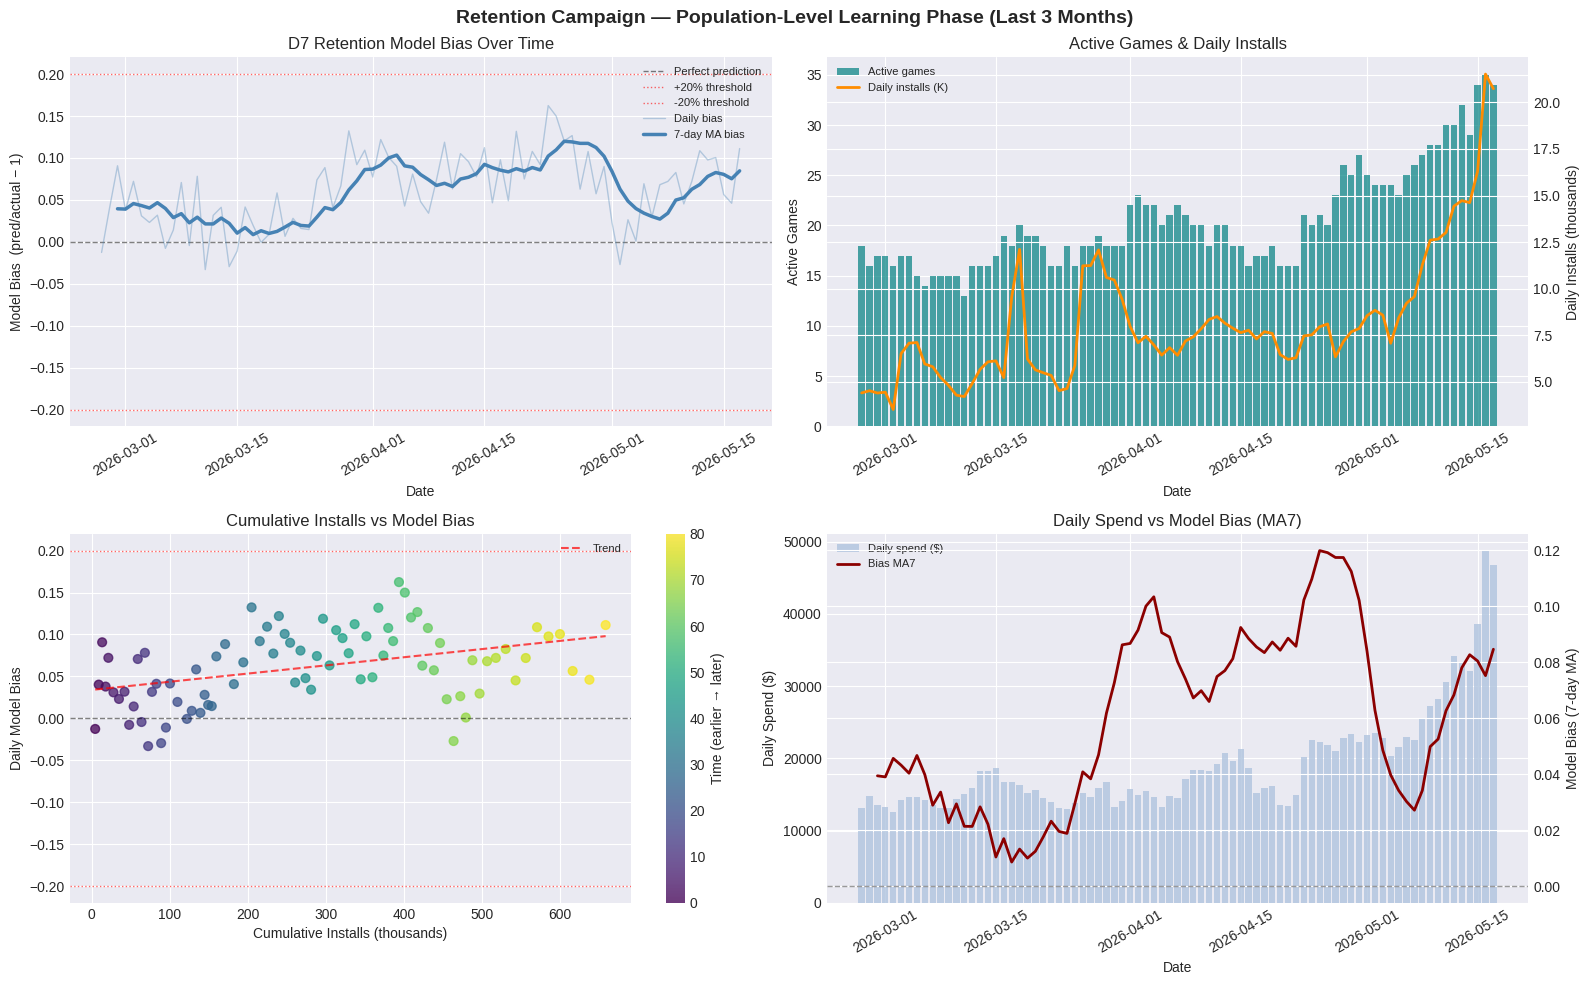


📊 Population-Level Summary:
   Mean daily model bias: 0.0612
   Std daily model bias:  0.0437
   Pct days within ±20%:  100.0%
   Correlation (cum_installs vs bias): 0.4070


In [ ]:
# Population-level aggregation by date
df_agg = df.groupby('date').agg(
    total_daily_installs=('daily_installs', 'sum'),
    total_retained_d7=('daily_retained_d7', 'sum'),
    total_ret_d7_prob_sum=('daily_ret_d7_prob_sum', 'sum'),
    total_spend=('daily_spend', 'sum'),
    active_games=('game_id', 'nunique')
).reset_index().sort_values('date')

df_agg['model_bias'] = df_agg['total_ret_d7_prob_sum'] / df_agg['total_retained_d7'].replace(0, np.nan) - 1
df_agg['model_bias_ma7'] = df_agg['model_bias'].rolling(window=7, min_periods=3).mean()
df_agg['cumulative_installs'] = df_agg['total_daily_installs'].cumsum()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Retention Campaign — Population-Level Learning Phase (Last 3 Months)', fontsize=14, fontweight='bold')

# Plot 1: Model bias over calendar time
ax1 = axes[0, 0]
ax1.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5, label='Perfect prediction')
ax1.axhline(0.2, color='red', linewidth=1, linestyle=':', alpha=0.6, label='+20% threshold')
ax1.axhline(-0.2, color='red', linewidth=1, linestyle=':', alpha=0.6, label='-20% threshold')
ax1.plot(df_agg['date'], df_agg['model_bias'], alpha=0.35, color='steelblue', linewidth=1, label='Daily bias')
ax1.plot(df_agg['date'], df_agg['model_bias_ma7'], color='steelblue', linewidth=2.5, label='7-day MA bias')
ax1.set_title('D7 Retention Model Bias Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Model Bias  (pred/actual − 1)')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=30)

# Plot 2: Active games over time
ax2 = axes[0, 1]
ax2.bar(df_agg['date'], df_agg['active_games'], color='teal', alpha=0.7, label='Active games')
ax2_twin = ax2.twinx()
ax2_twin.plot(df_agg['date'], df_agg['total_daily_installs'] / 1000, color='darkorange', linewidth=2, label='Daily installs (K)')
ax2.set_title('Active Games & Daily Installs')
ax2.set_xlabel('Date')
ax2.set_ylabel('Active Games')
ax2_twin.set_ylabel('Daily Installs (thousands)')
ax2.tick_params(axis='x', rotation=30)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# Plot 3: Cumulative installs vs model bias (scatter)
ax3 = axes[1, 0]
sc = ax3.scatter(df_agg['cumulative_installs'] / 1000, df_agg['model_bias'],
                 c=range(len(df_agg)), cmap='viridis', s=40, alpha=0.75)
ax3.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax3.axhline(0.2, color='red', linewidth=1, linestyle=':', alpha=0.6)
ax3.axhline(-0.2, color='red', linewidth=1, linestyle=':', alpha=0.6)
z = np.polyfit(df_agg['cumulative_installs'].dropna(), df_agg['model_bias'].dropna(), 1)
p = np.poly1d(z)
ax3.plot(df_agg['cumulative_installs'] / 1000, p(df_agg['cumulative_installs']), 'r--', linewidth=1.5, alpha=0.7, label='Trend')
plt.colorbar(sc, ax=ax3, label='Time (earlier → later)')
ax3.set_title('Cumulative Installs vs Model Bias')
ax3.set_xlabel('Cumulative Installs (thousands)')
ax3.set_ylabel('Daily Model Bias')
ax3.legend(fontsize=8)

# Plot 4: Spend over time + bias overlay
ax4 = axes[1, 1]
ax4.bar(df_agg['date'], df_agg['total_spend'], color='lightsteelblue', alpha=0.8, label='Daily spend ($)')
ax4_twin = ax4.twinx()
ax4_twin.plot(df_agg['date'], df_agg['model_bias_ma7'], color='darkred', linewidth=2, label='Bias MA7')
ax4_twin.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax4.set_title('Daily Spend vs Model Bias (MA7)')
ax4.set_xlabel('Date')
ax4.set_ylabel('Daily Spend ($)')
ax4_twin.set_ylabel('Model Bias (7-day MA)')
ax4.tick_params(axis='x', rotation=30)
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.show()

print('\n📊 Population-Level Summary:')
print(f'   Mean daily model bias: {df_agg["model_bias"].mean():.4f}')
print(f'   Std daily model bias:  {df_agg["model_bias"].std():.4f}')
print(f'   Pct days within ±20%:  {(df_agg["model_bias"].abs() < 0.2).mean()*100:.1f}%')
print(f'   Correlation (cum_installs vs bias): {np.corrcoef(df_agg["cumulative_installs"].dropna(), df_agg["model_bias"].dropna())[0,1]:.4f}')


## Step 5 — Learning Curve: Model Bias by Cumulative Installs Bucket

Bins all game-day observations by cumulative install count and computes median absolute bias
per bucket — showing when the model stabilizes as more data accumulates.


📊 Rows after outlier filter (5th–95th pct): 1,250 (from 1,390)

📊 Model Bias by Cumulative Install Bucket:
install_bin  median    mean    std  count  pct_within_20
       0–50 -0.1464 -0.0520 0.1836      5        80.0000
     50–100  0.0049  0.0228 0.1862      7        85.7143
    100–200 -0.0702 -0.0482 0.1108     32        87.5000
    200–500  0.0641  0.0670 0.1742     79        75.9494
     500–1K -0.0126  0.0065 0.1568    104        79.8077
      1K–2K  0.0107  0.0366 0.1654    148        77.7027
      2K–5K  0.0102  0.0359 0.1557    276        82.6087
     5K–10K  0.0304  0.0501 0.1535    276        82.2464
       10K+  0.0801  0.0818 0.1532    323        78.3282


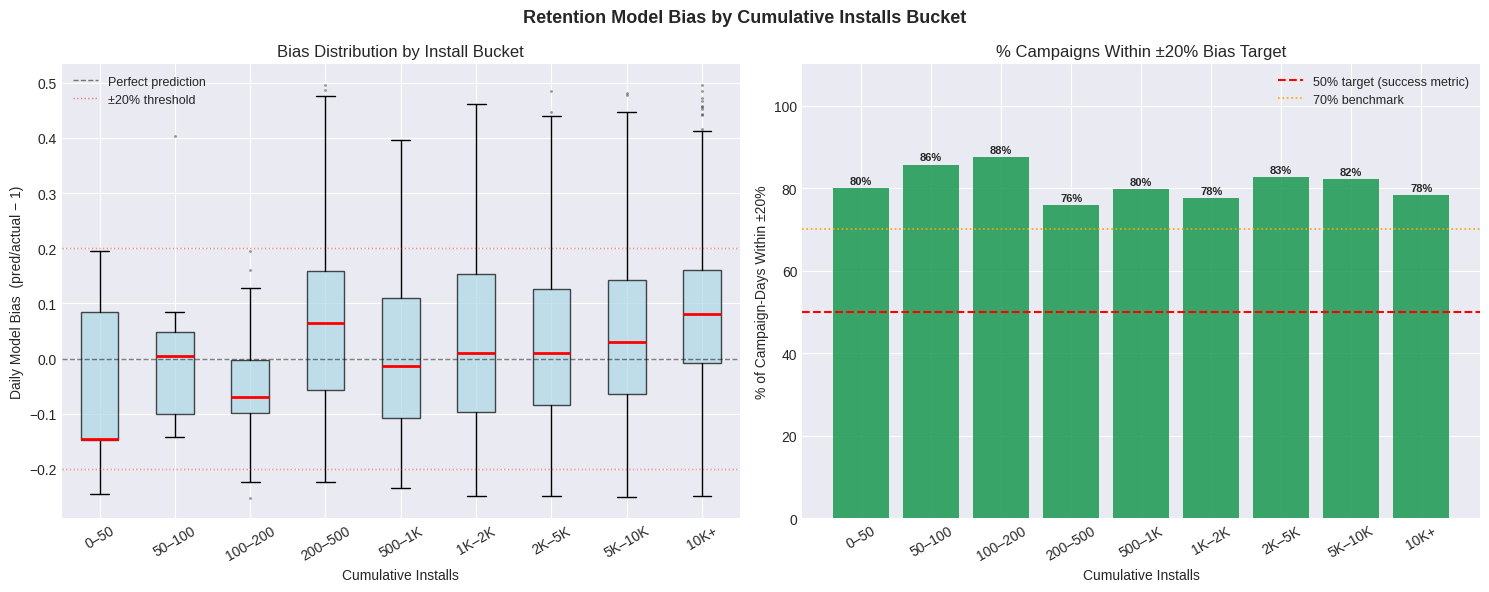

In [ ]:
# Filter to rows with valid model bias and meaningful installs
df_valid = df[df['daily_retained_d7'] > 5].copy()

# Clamp extreme outliers for display (keep 5th–95th percentile)
p5 = df_valid['daily_model_bias'].quantile(0.05)
p95 = df_valid['daily_model_bias'].quantile(0.95)
df_filtered = df_valid[
    (df_valid['daily_model_bias'] >= p5) &
    (df_valid['daily_model_bias'] <= p95)
].copy()
print(f'📊 Rows after outlier filter (5th–95th pct): {len(df_filtered):,} (from {len(df_valid):,})')

# Define install buckets
install_bins = [0, 50, 100, 200, 500, 1000, 2000, 5000, 10000, np.inf]
install_labels = ['0–50', '50–100', '100–200', '200–500', '500–1K', '1K–2K', '2K–5K', '5K–10K', '10K+']

df_filtered['install_bin'] = pd.cut(
    df_filtered['cumulative_installs'],
    bins=install_bins,
    labels=install_labels,
    right=False
)

bin_summary = df_filtered.groupby('install_bin', observed=True)['daily_model_bias'].agg(
    median='median',
    mean='mean',
    std='std',
    count='count',
    pct_within_20=lambda x: (x.abs() < 0.2).mean() * 100
).reset_index()

print('\n📊 Model Bias by Cumulative Install Bucket:')
print(bin_summary.to_string(index=False, float_format='{:.4f}'.format))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Retention Model Bias by Cumulative Installs Bucket', fontsize=13, fontweight='bold')

# Boxplot per bucket
ax1 = axes[0]
plot_data = [df_filtered[df_filtered['install_bin'] == b]['daily_model_bias'].dropna().values
             for b in install_labels if b in df_filtered['install_bin'].cat.categories]
valid_labels = [b for b in install_labels if b in df_filtered['install_bin'].cat.categories
                and len(df_filtered[df_filtered['install_bin'] == b]) > 0]
bps = ax1.boxplot(plot_data, labels=valid_labels, patch_artist=True,
                  medianprops=dict(color='red', linewidth=2),
                  flierprops=dict(marker='.', markersize=2, alpha=0.4))
for patch in bps['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
ax1.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5, label='Perfect prediction')
ax1.axhline(0.2, color='red', linewidth=1, linestyle=':', alpha=0.5, label='±20% threshold')
ax1.axhline(-0.2, color='red', linewidth=1, linestyle=':', alpha=0.5)
ax1.set_title('Bias Distribution by Install Bucket')
ax1.set_xlabel('Cumulative Installs')
ax1.set_ylabel('Daily Model Bias  (pred/actual − 1)')
ax1.tick_params(axis='x', rotation=30)
ax1.legend(fontsize=9)

# % within ±20% target per bucket
ax2 = axes[1]
colors = ['#d73027' if v < 50 else '#fee090' if v < 70 else '#1a9850' for v in bin_summary['pct_within_20']]
bars = ax2.bar(bin_summary['install_bin'].astype(str), bin_summary['pct_within_20'], color=colors, alpha=0.85)
ax2.axhline(50, color='red', linewidth=1.5, linestyle='--', label='50% target (success metric)')
ax2.axhline(70, color='orange', linewidth=1.2, linestyle=':', label='70% benchmark')
for bar, val in zip(bars, bin_summary['pct_within_20']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}%',
             ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.set_title('% Campaigns Within ±20% Bias Target')
ax2.set_xlabel('Cumulative Installs')
ax2.set_ylabel('% of Campaign-Days Within ±20%')
ax2.set_ylim(0, 110)
ax2.tick_params(axis='x', rotation=30)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Step 6 — Learning Curve by Days Since Campaign Start

Bins game-day observations by days since the campaign start, showing how model accuracy
evolves during the first weeks of a new Retention campaign (analogous to the learning phase).


📊 Model Bias by Days Since Campaign Start:
day_bin  median   mean    std  count  pct_within_20
   0–3d  0.0112 0.0188 0.1493    119        84.0336
   3–7d  0.0019 0.0221 0.1558    152        78.9474
  7–14d  0.0189 0.0317 0.1488    223        86.0987
 14–21d  0.0202 0.0480 0.1611    181        79.5580
 21–30d  0.0378 0.0571 0.1615    152        78.9474
 30–45d  0.0683 0.0722 0.1616    184        78.2609
 45–60d  0.0413 0.0614 0.1729    137        73.7226
   60d+  0.0969 0.0799 0.1461    102        81.3725


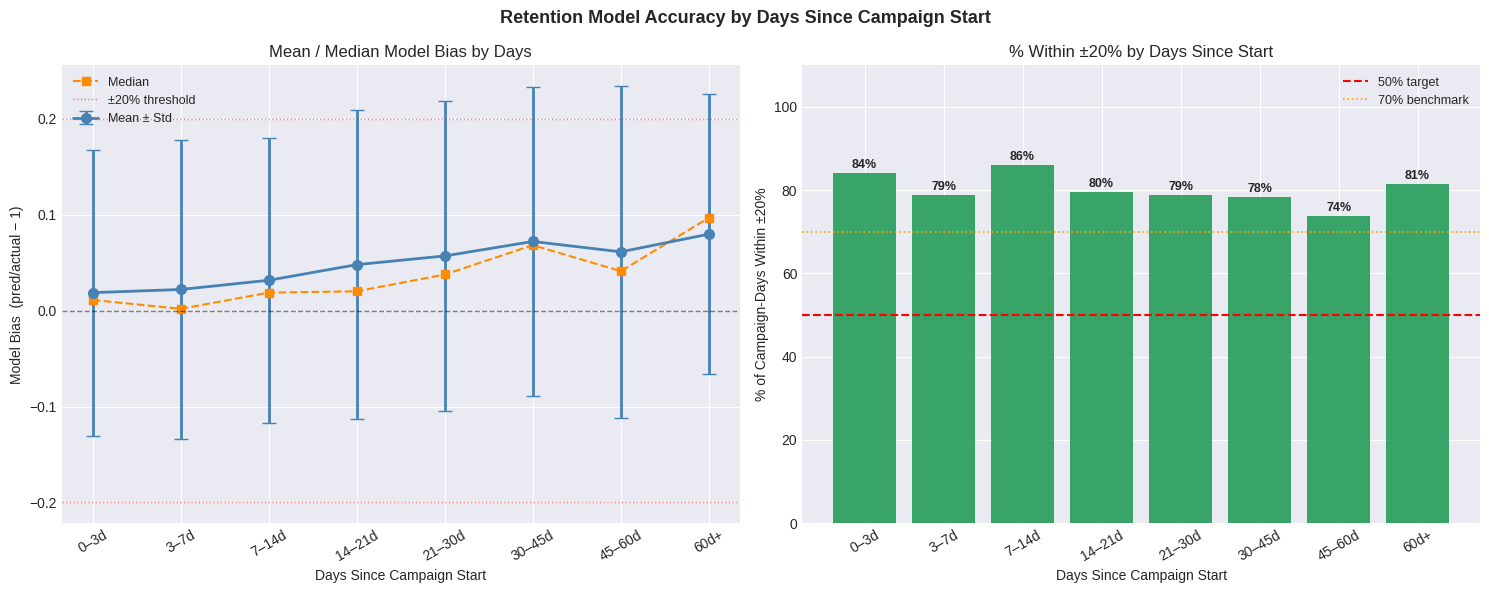

In [ ]:
day_bins  = [0, 3, 7, 14, 21, 30, 45, 60, np.inf]
day_labels = ['0–3d', '3–7d', '7–14d', '14–21d', '21–30d', '30–45d', '45–60d', '60d+']

df_filtered['day_bin'] = pd.cut(
    df_filtered['days_since_start'],
    bins=day_bins,
    labels=day_labels,
    right=False
)

day_summary = df_filtered.groupby('day_bin', observed=True)['daily_model_bias'].agg(
    median='median',
    mean='mean',
    std='std',
    count='count',
    pct_within_20=lambda x: (x.abs() < 0.2).mean() * 100
).reset_index()

print('📊 Model Bias by Days Since Campaign Start:')
print(day_summary.to_string(index=False, float_format='{:.4f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Retention Model Accuracy by Days Since Campaign Start', fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.errorbar(
    day_summary['day_bin'].astype(str),
    day_summary['mean'],
    yerr=day_summary['std'],
    fmt='o-', color='steelblue', linewidth=2, markersize=7, capsize=5, label='Mean ± Std'
)
ax1.plot(day_summary['day_bin'].astype(str), day_summary['median'],
         's--', color='darkorange', linewidth=1.5, markersize=6, label='Median')
ax1.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax1.axhline(0.2, color='red', linewidth=1, linestyle=':', alpha=0.5, label='±20% threshold')
ax1.axhline(-0.2, color='red', linewidth=1, linestyle=':', alpha=0.5)
ax1.set_title('Mean / Median Model Bias by Days')
ax1.set_xlabel('Days Since Campaign Start')
ax1.set_ylabel('Model Bias  (pred/actual − 1)')
ax1.tick_params(axis='x', rotation=30)
ax1.legend(fontsize=9)

ax2 = axes[1]
colors = ['#d73027' if v < 50 else '#fee090' if v < 70 else '#1a9850' for v in day_summary['pct_within_20']]
bars = ax2.bar(day_summary['day_bin'].astype(str), day_summary['pct_within_20'], color=colors, alpha=0.85)
ax2.axhline(50, color='red', linewidth=1.5, linestyle='--', label='50% target')
ax2.axhline(70, color='orange', linewidth=1.2, linestyle=':', label='70% benchmark')
for bar, val in zip(bars, day_summary['pct_within_20']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('% Within ±20% by Days Since Start')
ax2.set_xlabel('Days Since Campaign Start')
ax2.set_ylabel('% of Campaign-Days Within ±20%')
ax2.set_ylim(0, 110)
ax2.tick_params(axis='x', rotation=30)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


## Step 7 — Per-Game Deep-Dive: Top 20 Games by Spend

For each of the top 20 games, plots:
1. Daily installs + cumulative installs (left y-axis)
2. Model bias MA7 (right y-axis)

This makes it easy to see the individual learning trajectory and when bias stabilizes.


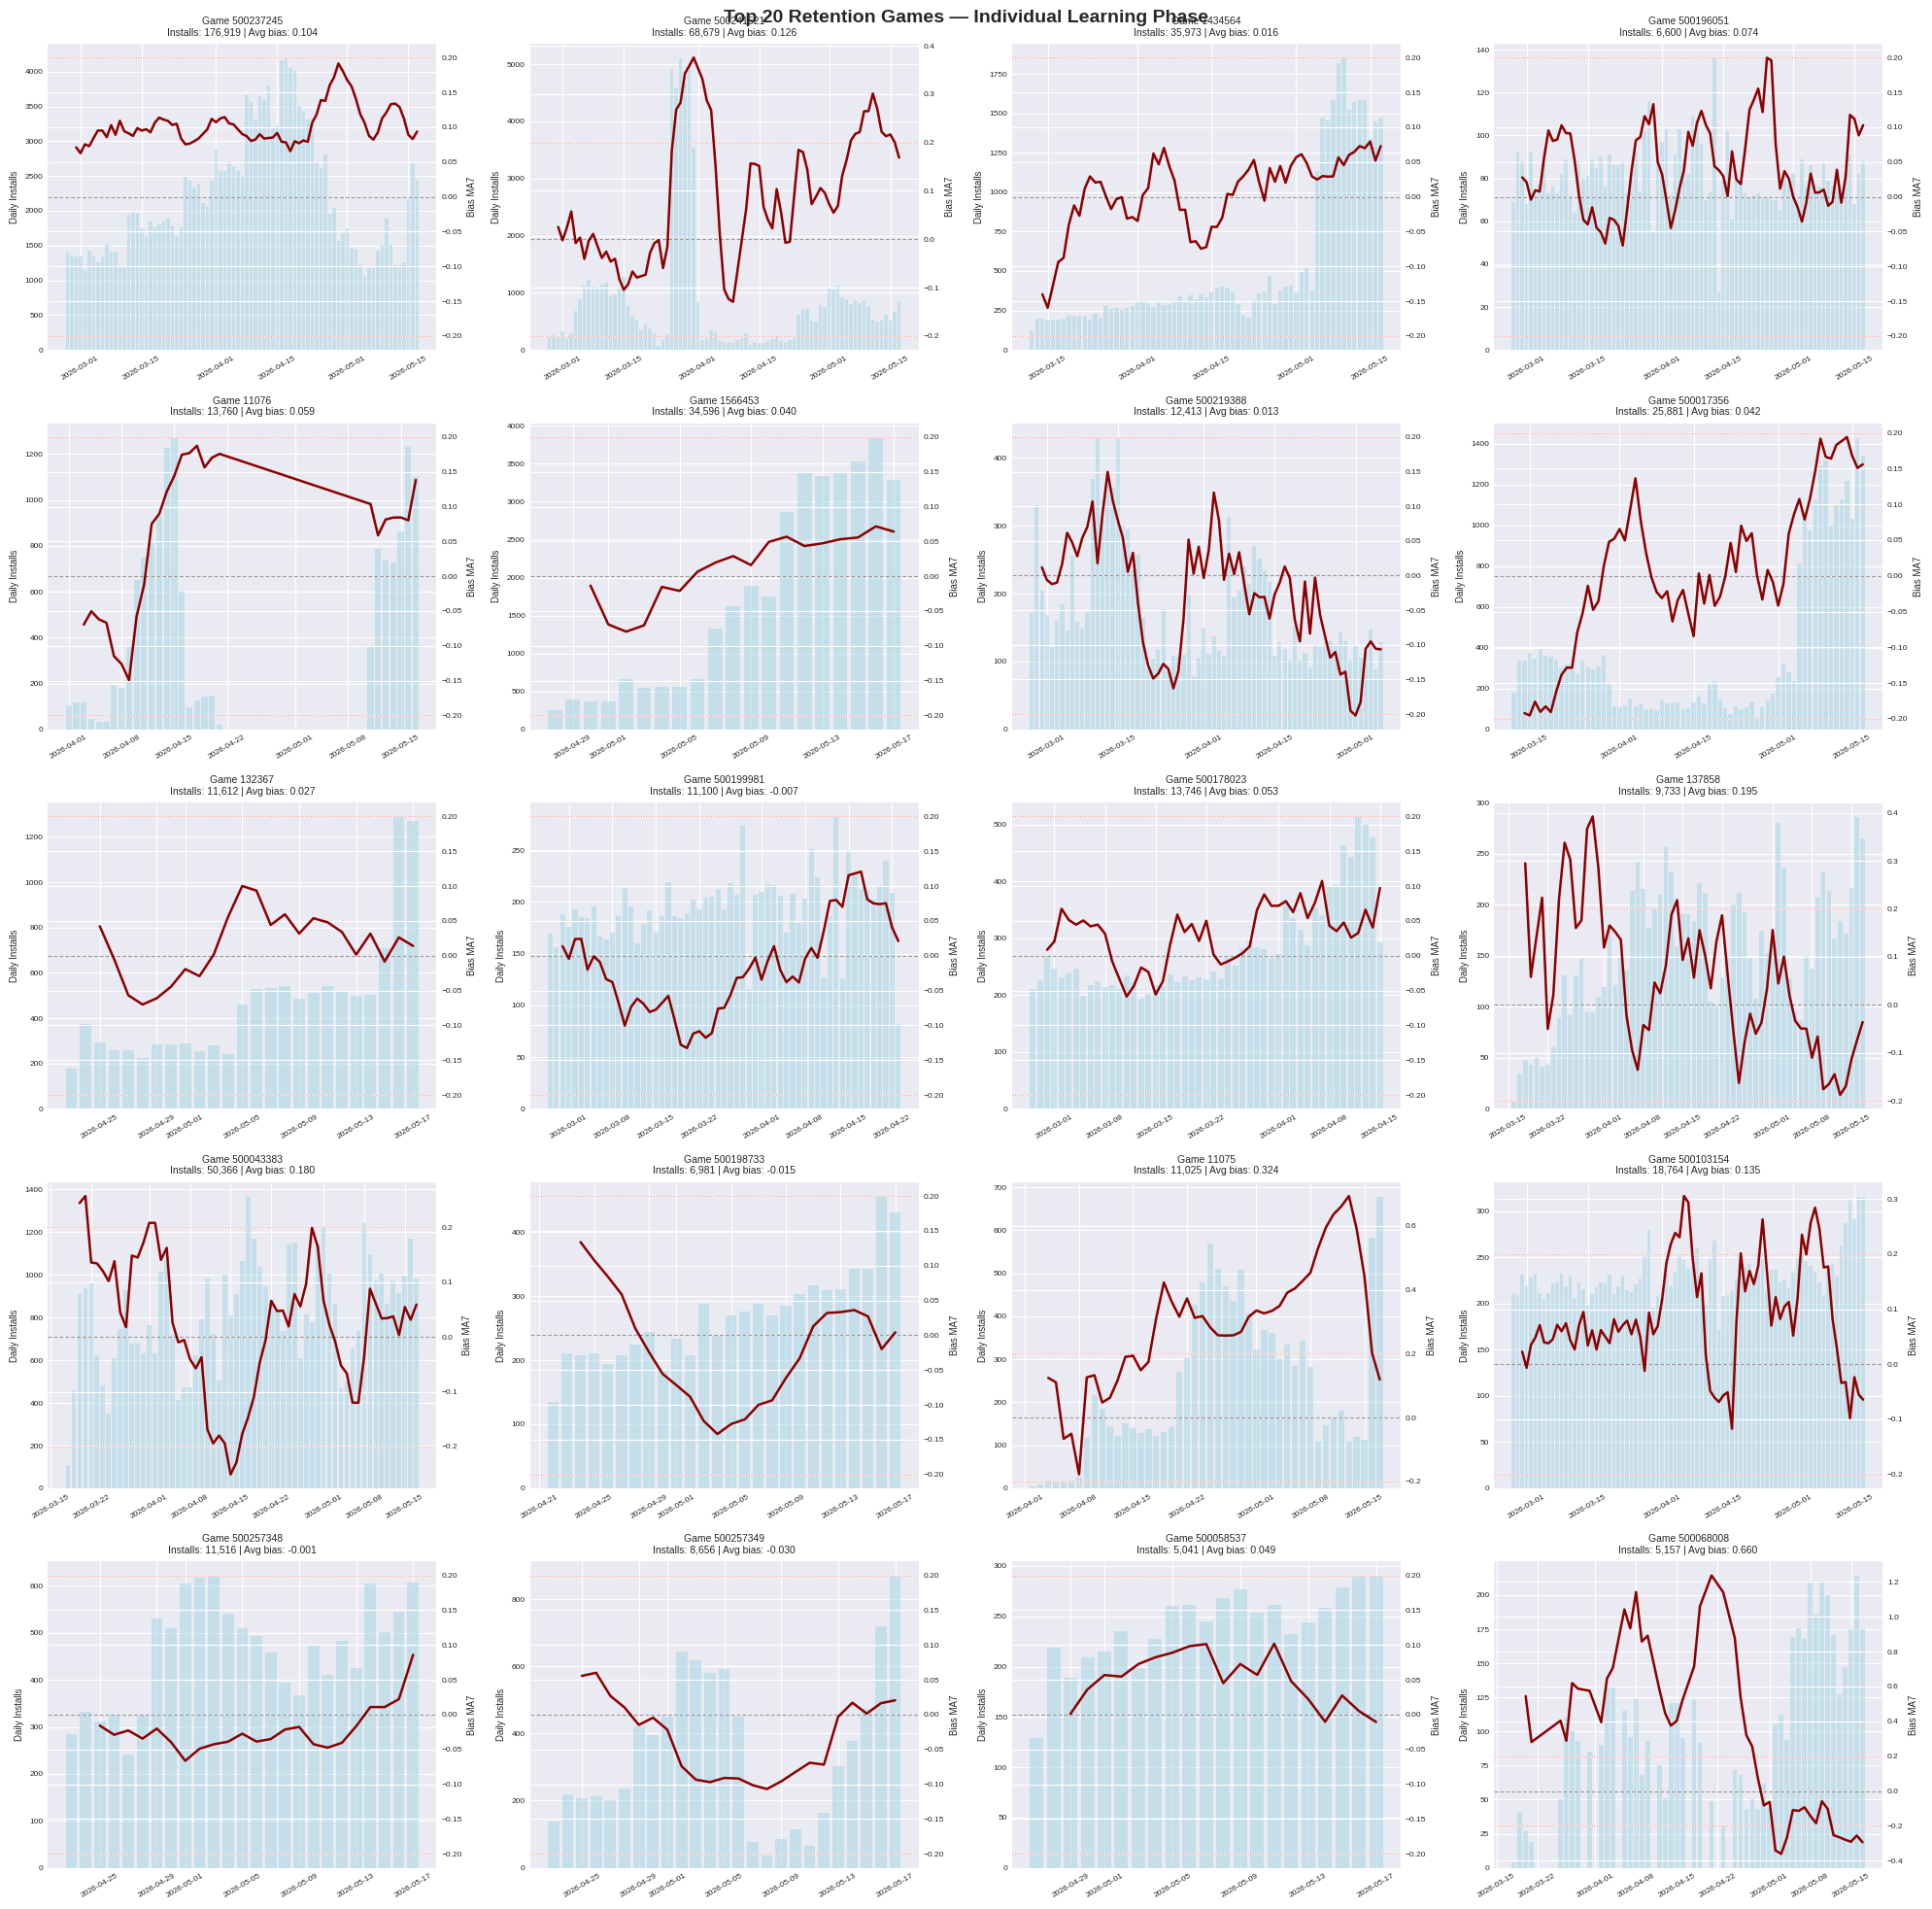

In [ ]:
# Select top 20 games by total spend from the game_list_df
top_games = game_list_df.head(20)['target_game_id'].astype(str).tolist()
df_top = df[df['game_id'].isin(top_games)].copy()

n_games = len(top_games)
n_cols = 4
n_rows = int(np.ceil(n_games / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('Top 20 Retention Games — Individual Learning Phase', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for idx, game_id in enumerate(top_games):
    game_data = df_top[df_top['game_id'] == game_id].sort_values('date')
    ax = axes_flat[idx]

    if len(game_data) < 3:
        ax.set_title(f'Game {game_id}\n(insufficient data)', fontsize=8)
        ax.axis('off')
        continue

    # Install bars
    ax.bar(game_data['date'], game_data['daily_installs'], color='lightblue', alpha=0.6, label='Daily installs')
    ax.set_ylabel('Daily Installs', fontsize=7)

    # Bias line on twin axis
    ax2 = ax.twinx()
    valid = game_data['model_bias_ma7'].notna()
    if valid.sum() >= 3:
        ax2.plot(game_data.loc[valid, 'date'], game_data.loc[valid, 'model_bias_ma7'],
                 color='darkred', linewidth=1.8, label='Bias MA7')
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax2.axhline(0.2, color='red', linewidth=0.7, linestyle=':', alpha=0.5)
    ax2.axhline(-0.2, color='red', linewidth=0.7, linestyle=':', alpha=0.5)
    ax2.set_ylabel('Bias MA7', fontsize=7)

    total_installs = game_data['cumulative_installs'].max()
    avg_bias = game_data['daily_model_bias'].mean()
    ax.set_title(f'Game {game_id}\nInstalls: {total_installs:,.0f} | Avg bias: {avg_bias:.3f}', fontsize=7.5)
    ax.tick_params(axis='x', labelsize=6, rotation=30)
    ax.tick_params(axis='y', labelsize=6)
    ax2.tick_params(axis='y', labelsize=6)

# Hide unused axes
for idx in range(n_games, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()


## Step 8 — Learning Phase Threshold Analysis

For each game, identifies the number of cumulative installs at which the model bias
first stabilizes within ±20%. Determines the distribution of this threshold across
all games to recommend a learning phase install target.


📊 Stabilization Analysis:
   Games with sufficient data: 58
   Games that stabilized (±20%, 3-day streak): 49 (84.5%)
   Games still learning: 9

   Cumulative installs at stabilization:
     Median: 564
     Mean:   855
     P25:    305
     P75:    928

   Days since start at stabilization:
     Median: 2.0 days
     Mean:   4.1 days
     P25:    2.0 days
     P75:    2.0 days


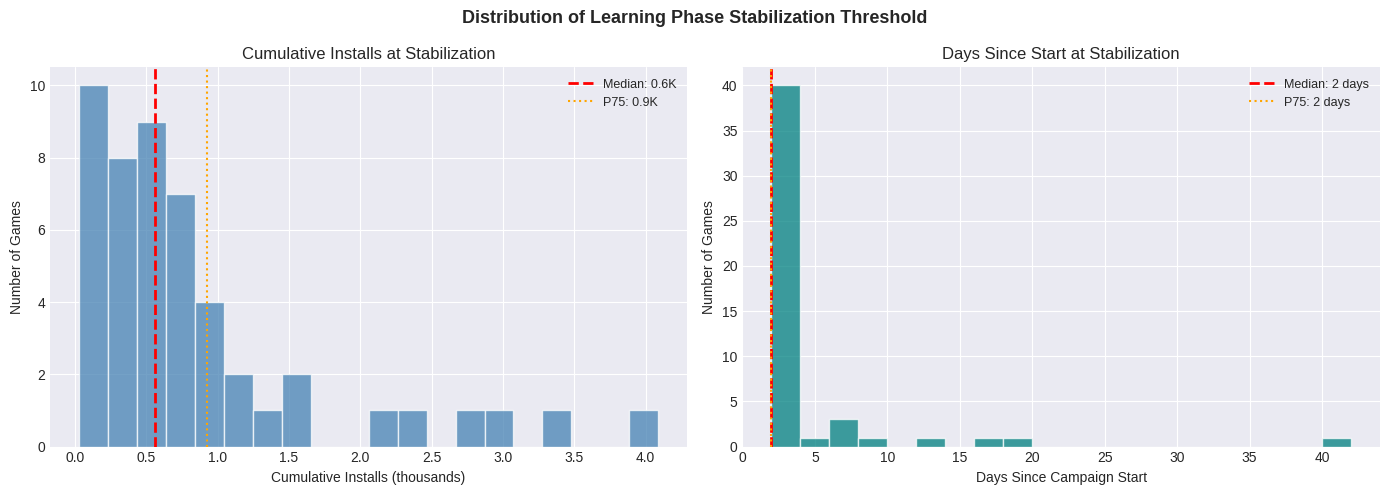

In [ ]:
# Identify for each game-day when bias crossed inside ±20% and stayed (3-day streak)
def find_stabilization_point(game_df):
    game_df = game_df.sort_values('date').reset_index(drop=True)
    game_df['within_20pct'] = game_df['model_bias_ma7'].abs() < 0.2
    # Find first 3-day streak inside ±20%
    for i in range(len(game_df) - 2):
        if game_df.loc[i, 'within_20pct'] and game_df.loc[i+1, 'within_20pct'] and game_df.loc[i+2, 'within_20pct']:
            return {
                'game_id': game_df['game_id'].iloc[0],
                'stabilization_installs': game_df.loc[i, 'cumulative_installs'],
                'stabilization_day': game_df.loc[i, 'days_since_start'],
                'stabilization_date': game_df.loc[i, 'date'],
                'total_installs': game_df['cumulative_installs'].max(),
                'days_tracked': game_df['days_since_start'].max(),
                'stabilized': True
            }
    return {
        'game_id': game_df['game_id'].iloc[0],
        'stabilization_installs': np.nan,
        'stabilization_day': np.nan,
        'stabilization_date': pd.NaT,
        'total_installs': game_df['cumulative_installs'].max(),
        'days_tracked': game_df['days_since_start'].max(),
        'stabilized': False
    }

df_valid_bias = df[df['model_bias_ma7'].notna()].copy()
stabilization_results = df_valid_bias.groupby('game_id', group_keys=False).apply(find_stabilization_point)
stab_df = pd.DataFrame(list(stabilization_results))

stab_success = stab_df[stab_df['stabilized']]
stab_fail    = stab_df[~stab_df['stabilized']]

print(f'📊 Stabilization Analysis:')
print(f'   Games with sufficient data: {len(stab_df)}')
print(f'   Games that stabilized (±20%, 3-day streak): {len(stab_success)} ({len(stab_success)/len(stab_df)*100:.1f}%)')
print(f'   Games still learning: {len(stab_fail)}')
if len(stab_success) > 0:
    print(f'\n   Cumulative installs at stabilization:')
    print(f'     Median: {stab_success["stabilization_installs"].median():,.0f}')
    print(f'     Mean:   {stab_success["stabilization_installs"].mean():,.0f}')
    print(f'     P25:    {stab_success["stabilization_installs"].quantile(0.25):,.0f}')
    print(f'     P75:    {stab_success["stabilization_installs"].quantile(0.75):,.0f}')
    print(f'\n   Days since start at stabilization:')
    print(f'     Median: {stab_success["stabilization_day"].median():.1f} days')
    print(f'     Mean:   {stab_success["stabilization_day"].mean():.1f} days')
    print(f'     P25:    {stab_success["stabilization_day"].quantile(0.25):.1f} days')
    print(f'     P75:    {stab_success["stabilization_day"].quantile(0.75):.1f} days')

# Plot stabilization threshold distribution
if len(stab_success) >= 5:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Distribution of Learning Phase Stabilization Threshold', fontsize=13, fontweight='bold')

    ax1 = axes[0]
    ax1.hist(stab_success['stabilization_installs'].dropna() / 1000, bins=20, color='steelblue', alpha=0.75, edgecolor='white')
    median_val = stab_success['stabilization_installs'].median() / 1000
    p75_val = stab_success['stabilization_installs'].quantile(0.75) / 1000
    ax1.axvline(median_val, color='red', linewidth=2, linestyle='--', label=f'Median: {median_val:.1f}K')
    ax1.axvline(p75_val, color='orange', linewidth=1.5, linestyle=':', label=f'P75: {p75_val:.1f}K')
    ax1.set_title('Cumulative Installs at Stabilization')
    ax1.set_xlabel('Cumulative Installs (thousands)')
    ax1.set_ylabel('Number of Games')
    ax1.legend(fontsize=9)

    ax2 = axes[1]
    ax2.hist(stab_success['stabilization_day'].dropna(), bins=20, color='teal', alpha=0.75, edgecolor='white')
    median_day = stab_success['stabilization_day'].median()
    p75_day = stab_success['stabilization_day'].quantile(0.75)
    ax2.axvline(median_day, color='red', linewidth=2, linestyle='--', label=f'Median: {median_day:.0f} days')
    ax2.axvline(p75_day, color='orange', linewidth=1.5, linestyle=':', label=f'P75: {p75_day:.0f} days')
    ax2.set_title('Days Since Start at Stabilization')
    ax2.set_xlabel('Days Since Campaign Start')
    ax2.set_ylabel('Number of Games')
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print('⚠️  Insufficient stabilized games for distribution plot')


## Step 9 — Alpha Game Performance Check

Focuses specifically on the 22 Alpha Test games from the Retention Alpha Test doc,
reporting their model accuracy and learning phase status.


📊 Alpha games found in dataset: 12 / 22

📊 Alpha Game Summary:


,game_id,first_date,last_date,total_installs,total_retained_d7,mean_daily_bias,pct_within_20,total_spend,days_tracked,stabilization_installs,stabilization_day,stabilized
11,500241521,2026-02-26,2026-05-17,68679,3794,0.126212,55.555556,99857.604025,80,705.0,2.0,True
5,500196051,2026-02-26,2026-05-17,6600,2265,0.073564,76.543210,81834.864477,80,249.0,2.0,True
6,500199981,2026-02-26,2026-04-23,11100,2748,-0.006810,91.228070,56367.042179,56,513.0,2.0,True
1,500103154,2026-02-26,2026-05-17,18764,1348,0.135086,59.259259,40806.970063,80,653.0,2.0,True
2,500149926,2026-02-26,2026-04-02,9378,2501,0.126939,80.555556,16911.968516,35,1057.0,2.0,True
3,500166235,2026-02-26,2026-03-19,25883,4799,-0.053450,86.363636,9125.359784,21,606.0,2.0,True
4,500177457,2026-02-26,2026-05-16,2687,747,0.209949,52.307692,6163.677006,79,149.0,2.0,True
0,500097353,2026-02-26,2026-03-20,1087,198,0.136774,39.130435,2241.681050,22,354.0,7.0,True
10,500238832,2026-04-01,2026-04-08,2519,533,0.079090,100.000000,1878.981506,7,1615.0,2.0,True
9,500238795,2026-04-01,2026-04-09,852,243,0.237706,55.555556,1400.469714,8,315.0,2.0,True


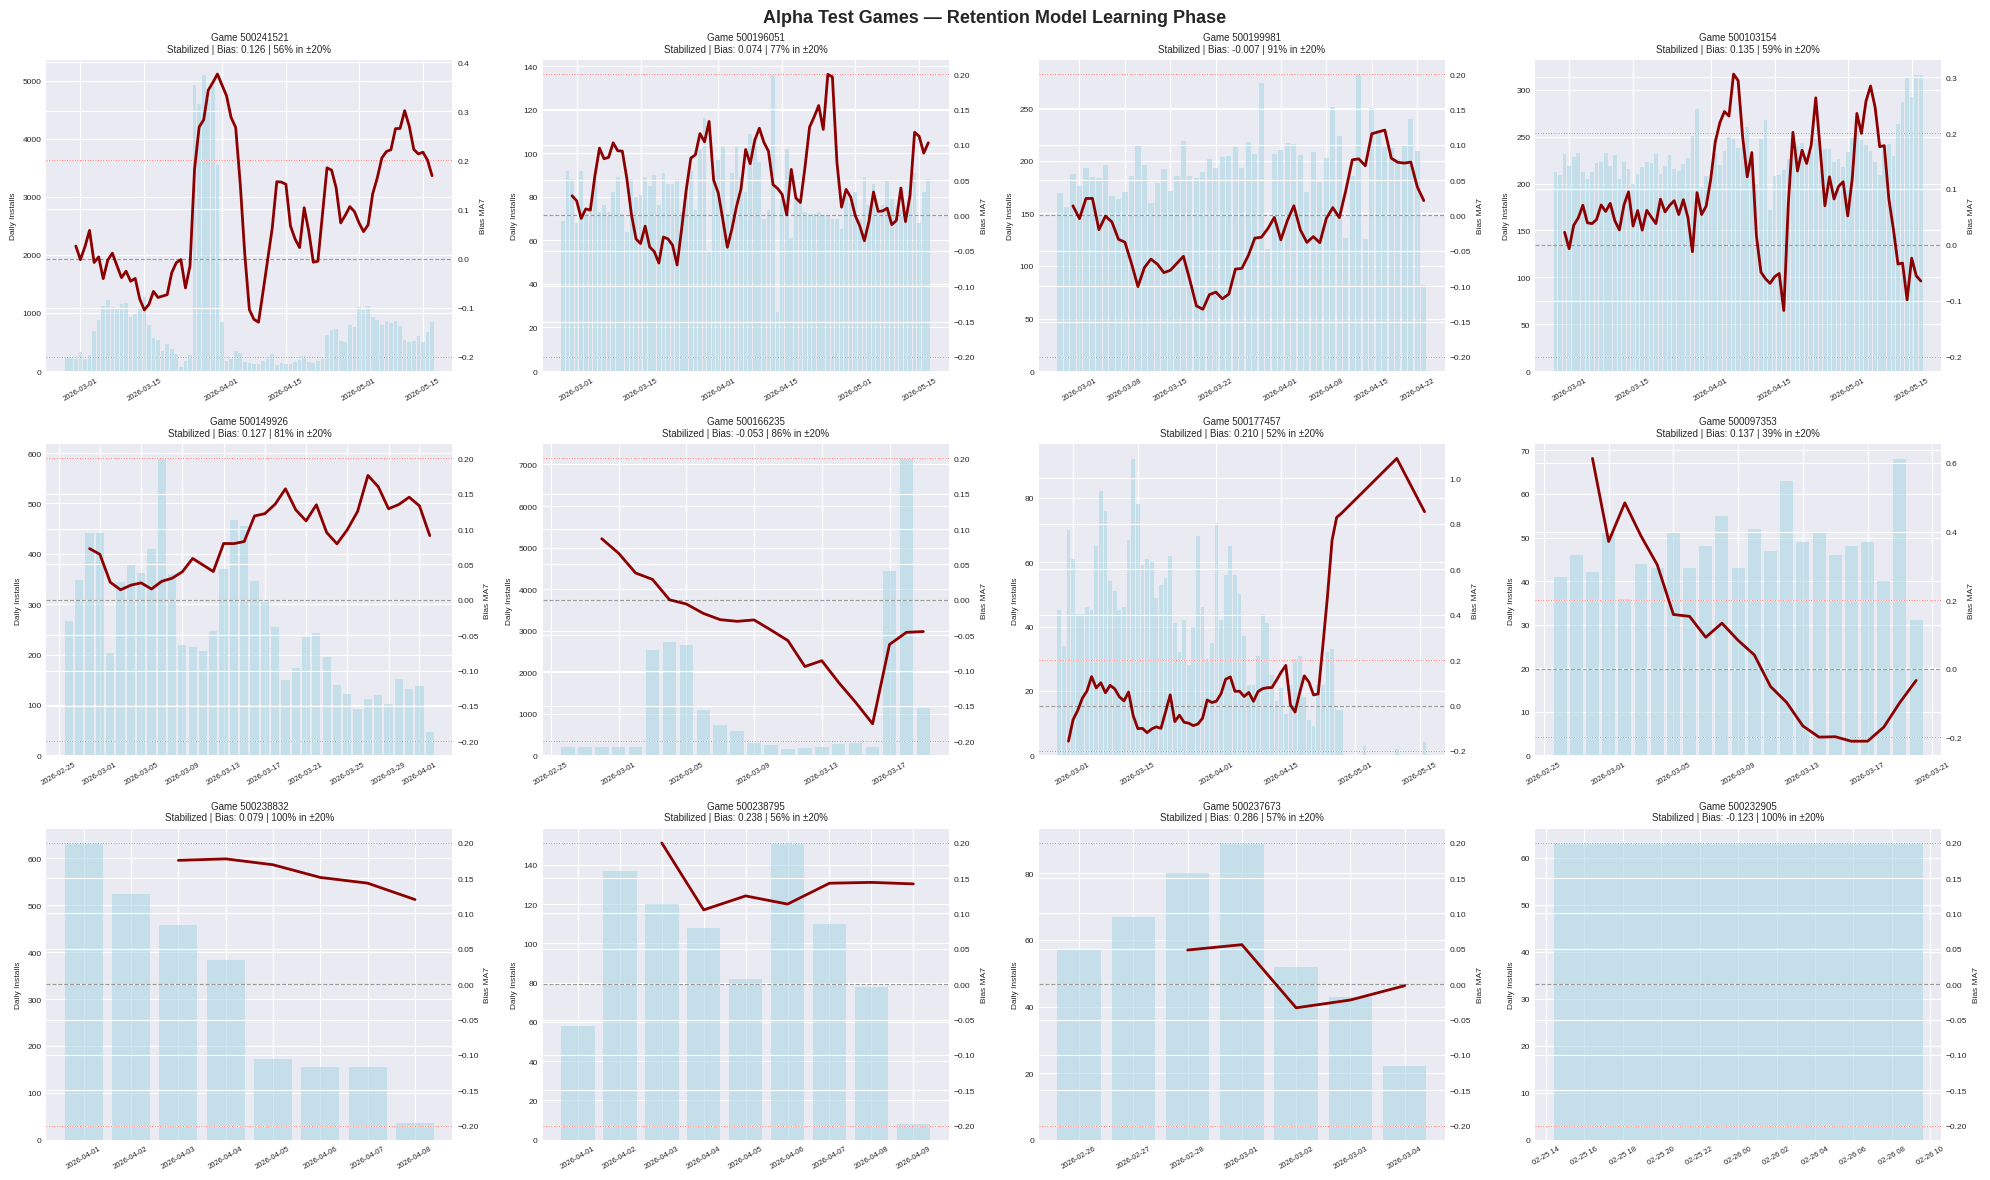

In [ ]:
ALPHA_GAME_IDS = [
    500085499, 500090629, 500097353, 500103154, 500149926,
    500166235, 500177457, 500195059, 500196051, 500199981,
    500206220, 500207188, 500209790, 500215793, 500232905,
    500237673, 500237674, 500238795, 500238832, 500241521,
    500241524, 500242067
]
alpha_game_ids_str = [str(g) for g in ALPHA_GAME_IDS]

df_alpha = df[df['game_id'].isin(alpha_game_ids_str)].copy()
found_alpha = df_alpha['game_id'].nunique()
print(f'📊 Alpha games found in dataset: {found_alpha} / {len(ALPHA_GAME_IDS)}')

if found_alpha == 0:
    print('⚠️  No Alpha games found in the queried data. They may not have sufficient D7 data yet.')
else:
    alpha_summary = df_alpha.groupby('game_id').agg(
        first_date=('date', 'min'),
        last_date=('date', 'max'),
        total_installs=('daily_installs', 'sum'),
        total_retained_d7=('daily_retained_d7', 'sum'),
        mean_daily_bias=('daily_model_bias', 'mean'),
        pct_within_20=('daily_model_bias', lambda x: (x.abs() < 0.2).mean() * 100),
        total_spend=('daily_spend', 'sum'),
        days_tracked=('days_since_start', 'max')
    ).reset_index()

    # Merge stabilization info
    alpha_summary = alpha_summary.merge(stab_df[['game_id','stabilization_installs','stabilization_day','stabilized']],
                                        on='game_id', how='left')
    alpha_summary = alpha_summary.sort_values('total_spend', ascending=False)

    print('\n📊 Alpha Game Summary:')
    display(alpha_summary)

    # Plot alpha games learning curves
    n_alpha = len(alpha_summary)
    n_cols_a = 4
    n_rows_a = int(np.ceil(n_alpha / n_cols_a))

    if n_alpha > 0:
        fig, axes = plt.subplots(n_rows_a, n_cols_a, figsize=(20, n_rows_a * 4))
        fig.suptitle('Alpha Test Games — Retention Model Learning Phase', fontsize=13, fontweight='bold')
        axes_flat = axes.flatten() if n_alpha > 1 else [axes]

        for idx, row in alpha_summary.iterrows():
            i = list(alpha_summary.index).index(idx)
            if i >= len(axes_flat):
                break
            ax = axes_flat[i]
            gd = df_alpha[df_alpha['game_id'] == row['game_id']].sort_values('date')

            ax.bar(gd['date'], gd['daily_installs'], color='lightblue', alpha=0.6)
            ax2 = ax.twinx()
            valid = gd['model_bias_ma7'].notna()
            if valid.sum() >= 2:
                ax2.plot(gd.loc[valid, 'date'], gd.loc[valid, 'model_bias_ma7'], color='darkred', linewidth=2)
            ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
            ax2.axhline(0.2, color='red', linewidth=0.7, linestyle=':', alpha=0.6)
            ax2.axhline(-0.2, color='red', linewidth=0.7, linestyle=':', alpha=0.6)

            stab_status = 'Stabilized' if row.get('stabilized') else 'Learning'
            ax.set_title(f'Game {row["game_id"]}\n{stab_status} | Bias: {row["mean_daily_bias"]:.3f} | {row["pct_within_20"]:.0f}% in ±20%',
                         fontsize=7)
            ax.tick_params(axis='x', labelsize=5.5, rotation=30)
            ax.tick_params(axis='y', labelsize=6)
            ax2.tick_params(axis='y', labelsize=6)
            ax.set_ylabel('Daily Installs', fontsize=6)
            ax2.set_ylabel('Bias MA7', fontsize=6)

        for i in range(n_alpha, len(axes_flat)):
            axes_flat[i].axis('off')

        plt.tight_layout()
        plt.show()


## Step 10 — Summary & Learning Phase Recommendation


In [ ]:
print('=' * 65)
print('RETENTION CAMPAIGN — LEARNING PHASE ANALYSIS SUMMARY')
print('=' * 65)
print(f'\nAnalysis window:  Last 3 months ({df["date"].min().date()} to {df["date"].max().date()})')
print(f'Games analyzed:   {df["game_id"].nunique()}')
print(f'Total rows:       {len(df):,}')

print('\n--- OVERALL MODEL ACCURACY ---')
overall_bias = (df['daily_ret_d7_prob_sum'].sum() / df['daily_retained_d7'].sum()) - 1
overall_pct_20 = (df['daily_model_bias'].abs() < 0.2).mean() * 100
print(f'Overall model bias (pred/actual − 1): {overall_bias:.4f}')
print(f'Campaign-days within ±20%:            {overall_pct_20:.1f}% (target: ≥50%)')

print('\n--- LEARNING PHASE THRESHOLD ---')
if len(stab_success) > 0:
    print(f'Median installs to stabilize:   {stab_success["stabilization_installs"].median():,.0f}')
    print(f'Median days to stabilize:       {stab_success["stabilization_day"].median():.0f}')
    print(f'P75 installs to stabilize:      {stab_success["stabilization_installs"].quantile(0.75):,.0f}')
    print(f'P75 days to stabilize:          {stab_success["stabilization_day"].quantile(0.75):.0f}')
else:
    print('⚠️  Insufficient data to compute stabilization threshold — more campaigns needed.')

print('\n--- ALPHA TEST CAMPAIGNS ---')
if found_alpha > 0:
    print(f'Alpha games with D7 data:   {found_alpha} / {len(ALPHA_GAME_IDS)}')
    alpha_pct_20 = (df_alpha['daily_model_bias'].abs() < 0.2).mean() * 100
    print(f'Alpha campaign-days ±20%:   {alpha_pct_20:.1f}%')
else:
    print('No Alpha game data available yet.')

print('\n--- RECOMMENDATION ---')
print('Based on the Doc guidance (FAQ #11): recommend waiting 2 weeks')
print('before making changes. This analysis provides the data-driven')
print('threshold in cumulative installs / days to confirm that guidance.')
print('=' * 65)


RETENTION CAMPAIGN — LEARNING PHASE ANALYSIS SUMMARY

Analysis window:  Last 3 months (2026-02-26 to 2026-05-17)
Games analyzed:   60
Total rows:       1,657

--- OVERALL MODEL ACCURACY ---
Overall model bias (pred/actual − 1): 0.0628
Campaign-days within ±20%:            64.3% (target: ≥50%)

--- LEARNING PHASE THRESHOLD ---
Median installs to stabilize:   564
Median days to stabilize:       2
P75 installs to stabilize:      928
P75 days to stabilize:          2

--- ALPHA TEST CAMPAIGNS ---
Alpha games with D7 data:   12 / 22
Alpha campaign-days ±20%:   67.1%

--- RECOMMENDATION ---
Based on the Doc guidance (FAQ #11): recommend waiting 2 weeks
before making changes. This analysis provides the data-driven
threshold in cumulative installs / days to confirm that guidance.
